# **Prepare Environment**

In [ ]:
!pip install scikit-learn seaborn -q

import numpy as np
import pandas as pd

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
# SKLEARN PREPROCESSING
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
# EVALUATION
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve
)
# IMBALANCE HANDLING
from imblearn.over_sampling import SMOTE
# PIPELINE FOR SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(42)
print('Environment ready')

Environment ready


# **Load Dataset**

In [ ]:
columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data", names=columns)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# ***Stage 0: Data Audit, Cleaning & EDA***

# Missing Value Audit

In [ ]:
# Replace "?" with NaN and convert all columns to numeric
df.replace("?", np.nan, inplace=True)
df = df.apply(pd.to_numeric)

# Missing Value Audit
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_audit = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_percent.values
})

print("Missing Value Audit:")
display(missing_audit)

# Convert target into binary classification
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Final dataset overview
print("Dataset Information:")
df.info()

print("\nTarget Class Distribution:")
print(df['target'].value_counts())

print("\nStatistical Summary:")
display(df.describe())

print("\nFirst Five Rows:")
display(df.head())

Missing Value Audit:


,Column,Missing Count,Missing %
0,age,0,0.000000
1,sex,0,0.000000
2,cp,0,0.000000
3,trestbps,0,0.000000
4,chol,0,0.000000
5,fbs,0,0.000000
6,restecg,0,0.000000
7,thalach,0,0.000000
8,exang,0,0.000000
9,oldpeak,0,0.000000


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Target Class Distribution:
target
0    164
1    139
Name: count, dtype: int64

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



First Five Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Missing values were found in the ca and thal columns with 1.32% and 0.66% missing data respectively. The strategy chosen is median imputation. This is to replace missing values with median values of the column instead of deleting the rows completely. Therefore, all the patients records can be preserved. Median is less sensitive to extreme values compared to mean.

# Outlier Analysis

In [ ]:
# Categorical
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal','ca']
print("Categorical columns:")
print(cat_cols)
print("")

# Continuous
cont_cols = [col for col in df.columns if col not in cat_cols + ['target']]
print("Continuous columns:")
print(cont_cols)

Categorical columns:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']

Continuous columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


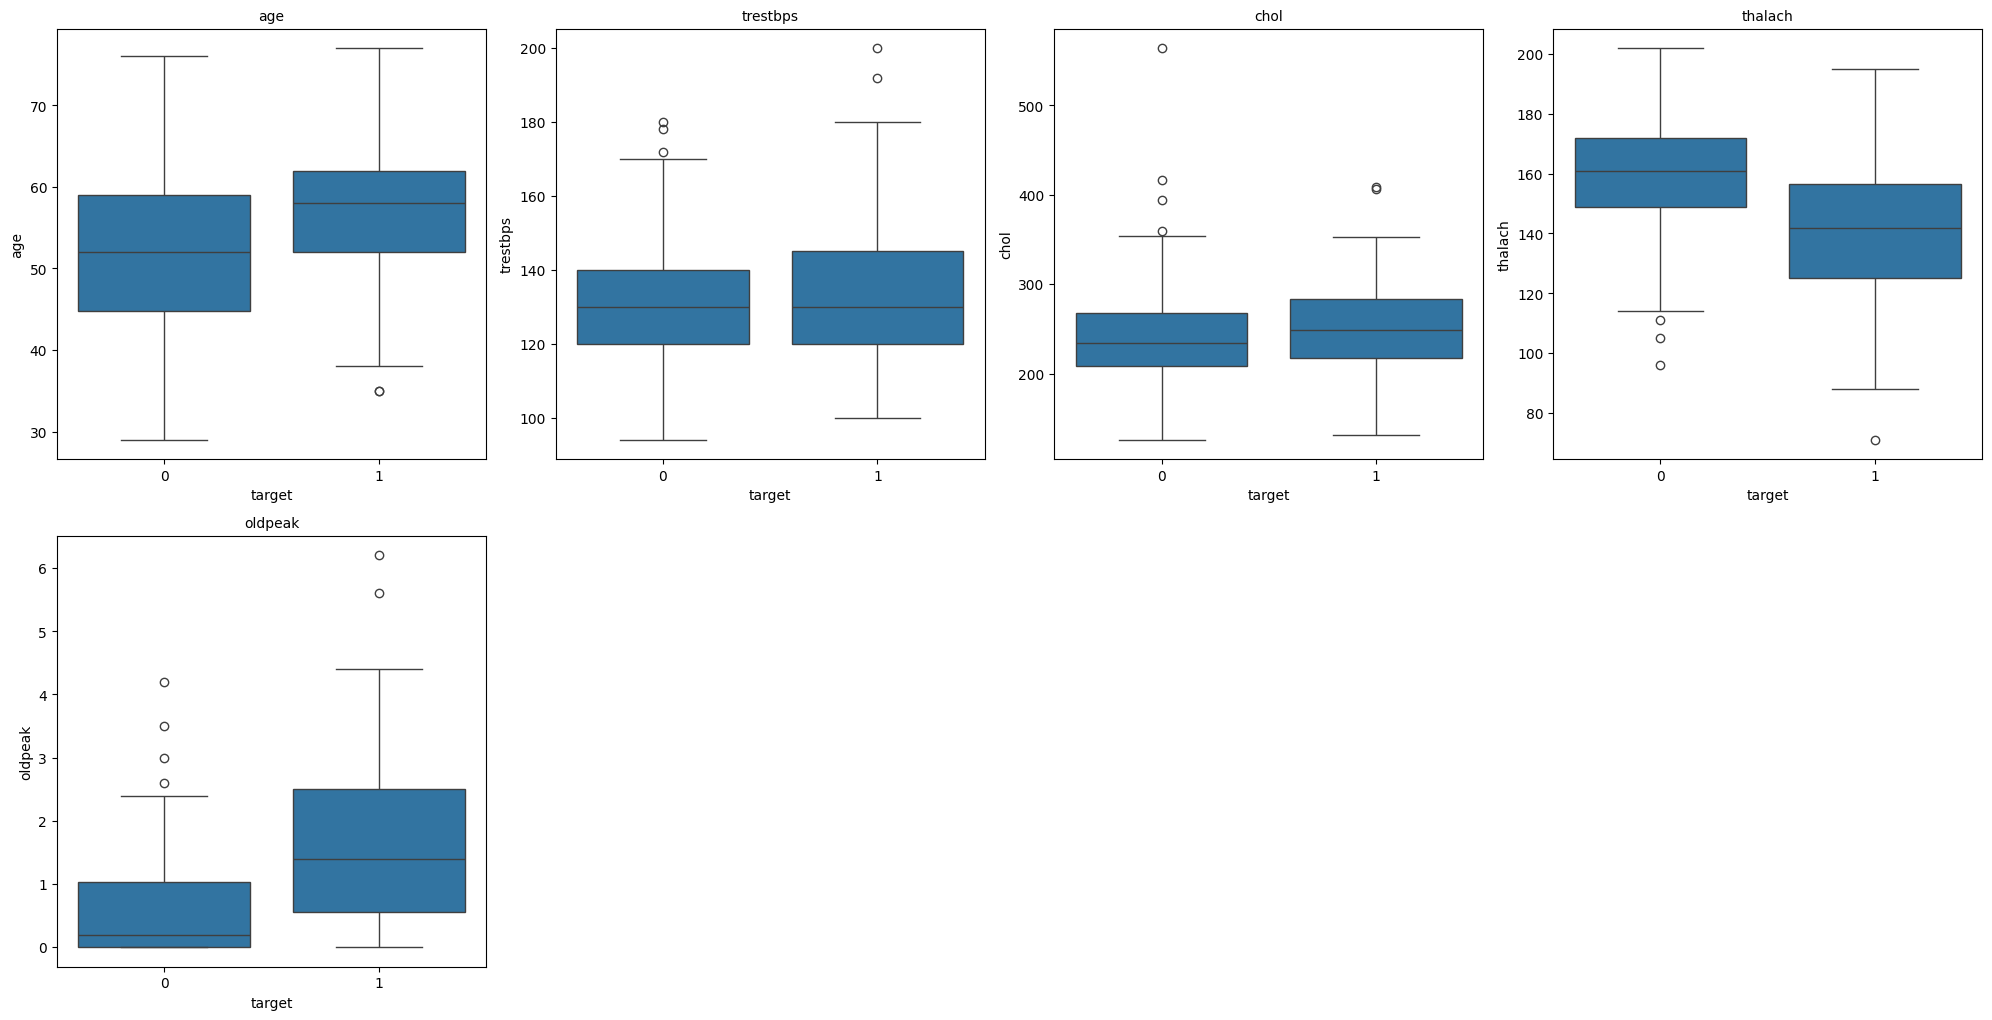

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    if i < len(axes):
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1)
plt.show()

In [ ]:
print('Outlier Report:')

outlier_report = []

for col in cont_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_report.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR" : IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Values": outliers.shape[0]
    })

    if not outliers.empty:
        print(f"\nColumn '{col}':")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Outlier values (first 5):\n{outliers[[col, 'target']].head()}")
    else:
        print(f"\nColumn '{col}': No outliers found.")


outlier_df=pd.DataFrame(outlier_report)
outlier_df.set_index('Feature', inplace=True)
print("")
print(outlier_df)







Outlier Report:

Column 'age': No outliers found.

Column 'trestbps':
  Number of outliers: 9
  Outlier values (first 5):
     trestbps  target
14      172.0       0
83      180.0       1
126     200.0       1
172     174.0       1
183     178.0       0

Column 'chol':
  Number of outliers: 5
  Outlier values (first 5):
      chol  target
48   417.0       0
121  407.0       1
152  564.0       0
173  394.0       0
181  409.0       1

Column 'thalach':
  Number of outliers: 1
  Outlier values (first 5):
     thalach  target
245     71.0       1

Column 'oldpeak':
  Number of outliers: 5
  Outlier values (first 5):
     oldpeak  target
91       6.2       1
123      5.6       1
183      4.2       0
191      4.2       1
285      4.4       1

             Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Values
Feature                                                               
age        48.0   61.0  13.0        28.50        80.50               0
trestbps  120.0  140.0  20.0        90.0

The outliers were keep inside the dataset. This is because extremely high values of trestbps, chol, thalach and oldpeak may indicate genuinely severe heart disease instead of data errors. Removing the outliers may reduce the model's ability to learn meaningful patterns.

# Class Distribution

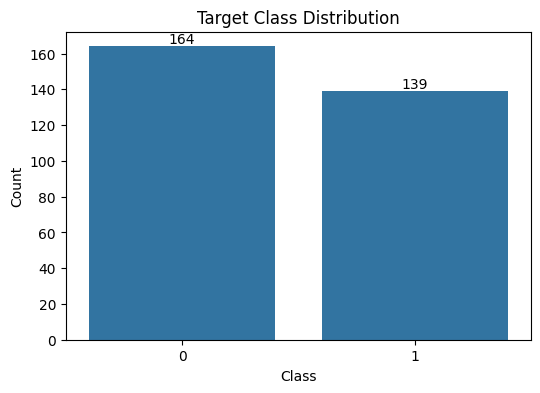

0=No heart disease, 1=Heart disease


In [ ]:
# Bar chart of the target class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df)
ax.bar_label(ax.containers[0])
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

print("0=No heart disease, 1=Heart disease")

In [ ]:
from numpy._core.defchararray import count
count_0 = len(df[df['target'] == 0])
count_1 = len(df[df['target'] == 1])
print("No heart disease:", count_0)
print("Heart disease:", count_1)

total_count = len(df)
print("Total count:", total_count)

ratio_0 = count_0 / total_count
ratio_1 = count_1 / total_count

print("")
print(f"Ratio of class 0: {ratio_0:.2f}")
print(f"Percentage of class 0: {ratio_0*100:.2f}%")
print("")
print(f"Ratio of class 1: {ratio_1:.2f}")
print(f"Percentage of class 1: {ratio_1*100:.2f}%")

No heart disease: 164
Heart disease: 139
Total count: 303

Ratio of class 0: 0.54
Percentage of class 0: 54.13%

Ratio of class 1: 0.46
Percentage of class 1: 45.87%


The class distribution plot shows that the dataset contains 164 samples without heart disease (54.13%) and 139 samples with heart disease (45.87%). Since both classes represent more than 20% of the dataset, the dataset is considered relatively balanced and does not have severe class imbalance. However, SMOTE was still applied during training to improve the model's ability to detect heart disease cases because false negatives in medical diagnosis are costly.

# EDA Visualisation

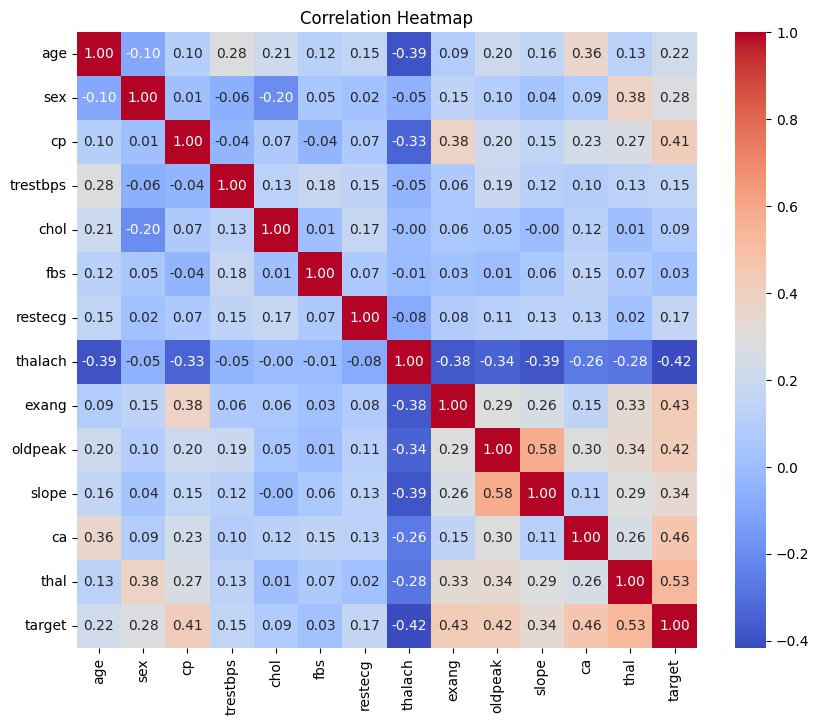

In [ ]:
all_cols = [col for col in df.columns if col != 'target']
corr_data = df[all_cols+['target']]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

The feature with the highest correlation to the target is thal with positive correlation value of 0.53. This means that the higher the thalassemia, the higher the risk of heart disease. Features such as ca, exang, oldpeak and cp have moderate positive correlation to target with value of 0.46, 0.43, 0.42 and 0.41 respectively. In contrast, thalach has a negative correlation with target which is -0.42.

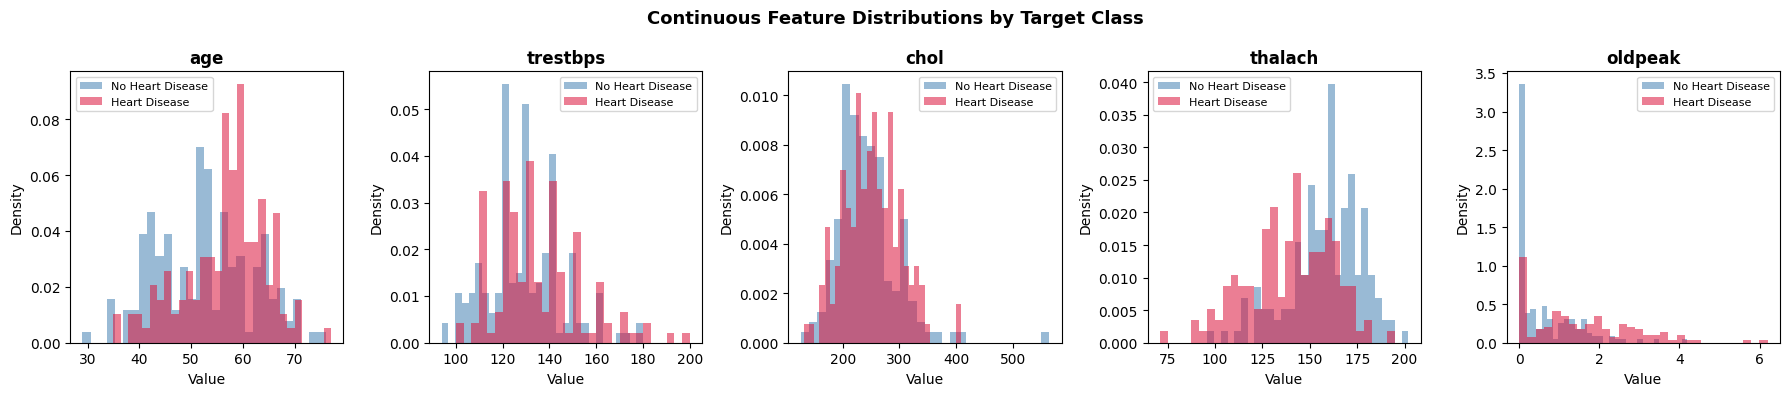

In [ ]:
numeric_features = cont_cols # Use the previously defined continuous columns

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 4))
# Ensure axes is an iterable even for a single subplot
if len(numeric_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, numeric_features):
    for label, color, name in [(0, 'steelblue', 'No Heart Disease'), (1, 'crimson', 'Heart Disease')]:
        subset = df[df['target'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Continuous Feature Distributions by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Patients with heart disease tend to be older, have lower maximum thalach and higher oldpeak values compared to patients without heart disease. Features such as trestbps and chol show overlapping distributions showing weaker separation between classes. This means that features like age, thalach and oldpeak is more useful compared to trestbps and chol.

# Feature engineering

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
#One Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1.0,cp_2.0,cp_3.0,cp_4.0,...,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0,ca_1.0,ca_2.0,ca_3.0
0,63.0,145.0,233.0,150.0,2.3,0,True,False,False,False,...,False,True,False,False,True,True,False,False,False,False
1,67.0,160.0,286.0,108.0,1.5,1,True,False,False,True,...,False,True,True,True,False,False,False,False,False,True
2,67.0,120.0,229.0,129.0,2.6,1,True,False,False,True,...,False,True,True,True,False,False,True,False,True,False
3,37.0,130.0,250.0,187.0,3.5,0,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,41.0,130.0,204.0,172.0,1.4,0,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
print("Columns after encoding:")
print(df.columns.tolist())
print("")

Columns after encoding:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0', 'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0', 'ca_1.0', 'ca_2.0', 'ca_3.0']



In [ ]:
# Calculate skewness only for the original continuous columns
print(df[cont_cols].skew())

age        -0.209060
trestbps    0.706035
chol        1.135503
thalach    -0.537449
oldpeak     1.269720
dtype: float64


Feature encoding was applied to categorical variables such as sex, cp, fbs, restecg, exang, slope, ca and thal using one-hot encoding to convert them into numerical format.

Log transform was not applied because the skewness values are below the threshold 2.

# ***Stage 0b: Handling Class Imbalance***

In [ ]:
# from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE

X = df.drop('target', axis=1)
y = df['target']

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Imputation
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scaling
sc = StandardScaler()

X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
target
0    131
1    111
Name: count, dtype: int64

After SMOTE:
target
1    131
0    131
Name: count, dtype: int64


Before SMOTE, the training dataset showed slight class imbalance with 131 samples in class 0 and 111 samples in class 1. SMOTE was applied to generate synthetic samples for the minority class. This result in a balanced class distribution of 131 samples for each class. SMOTE helps reduce model bias toward the majority class and improves the model's ability to correctly identify patients with heart disease.

# ***Stage A: Classical/Baseline Model***



In [ ]:
clf=LogisticRegression(max_iter=1000,random_state=42)
clf.fit(X_train_smote, y_train_smote)
y_pred=clf.predict(X_test_s)

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, clf.predict_proba(X_test_s)[:,1]))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.80      0.86      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

ROC-AUC: 0.9502164502164503


The Logistic Regression baseline model achieved an accuracy of 84% with an ROC-AUC score of 0.95. This shows a strong overall classification performance. The model achieved a recall score of 0.86 for patients with heart disease (class 1), meaning that 86% of actual heart disease cases were correctly identified. This is important in the medical context because false negatives are critical. The balanced precision and recall values in both class 0 and class 1 suggest that the model generalises well despite the small dataset size.

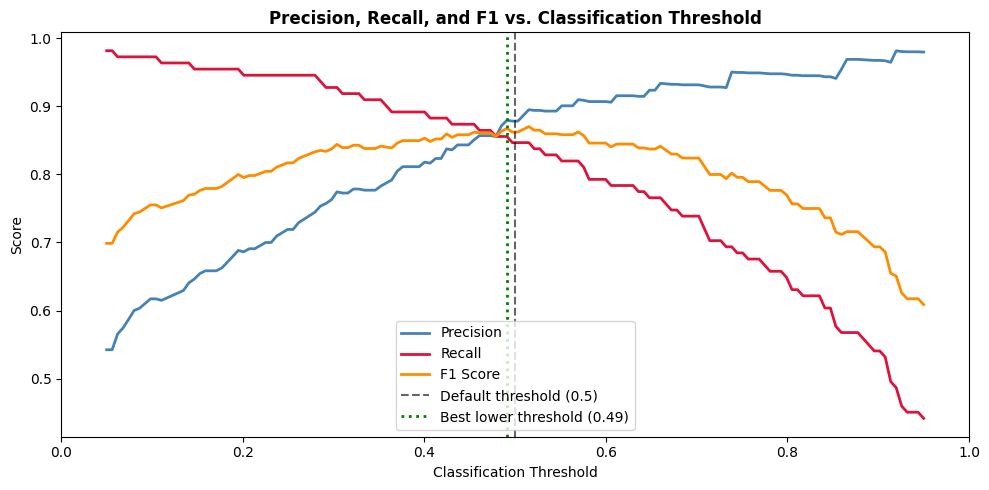


At threshold = 0.50:  P=0.879  R=0.847  F1=0.862

Best threshold = 0.49:  P=0.880  R=0.856  F1=0.868


In [ ]:
probs = clf.predict_proba(X_train_s)[:,1]
thresholds = np.linspace(0.05, 0.95, 150)
precisions, recalls, f1_scores_t = [], [], []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)
    precisions.append(precision_score(y_train, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_train, y_pred_t, zero_division=0))
    f1_scores_t.append(f1_score(y_train, y_pred_t, zero_division=0))

# Find best F1 only for thresholds 0.50
lower_thresholds = thresholds[thresholds < 0.50]
lower_f1_scores = np.array(f1_scores_t)[thresholds < 0.50]

best_lower_idx = np.argmax(lower_f1_scores)
best_lower_thresh = lower_thresholds[best_lower_idx]

original_idx = np.where(thresholds == best_lower_thresh)[0][0]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions,   color='steelblue',  lw=2, label='Precision')
plt.plot(thresholds, recalls,      color='crimson',    lw=2, label='Recall')
plt.plot(thresholds, f1_scores_t,  color='darkorange', lw=2, label='F1 Score')

plt.axvline(0.5, color='black', linestyle='--', alpha=0.6,
            label='Default threshold (0.5)')

plt.axvline(best_lower_thresh, color='green', linestyle=':', lw=2,
            label=f'Best lower threshold ({best_lower_thresh:.2f})')

plt.xlim(0, 1.0)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 vs. Classification Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nAt threshold = 0.50:  '
      f'P={precision_score(y_train,(probs>=0.5).astype(int)):.3f}  '
      f'R={recall_score(y_train,(probs>=0.5).astype(int)):.3f}  '
      f'F1={f1_score(y_train,(probs>=0.5).astype(int)):.3f}')

print(f'\nBest threshold = {best_lower_thresh:.2f}:  '
      f'P={precisions[original_idx]:.3f}  '
      f'R={recalls[original_idx]:.3f}  '
      f'F1={f1_scores_t[original_idx]:.3f}')

The threshold tuning analysis was done to see how changing the classification threshold affects the performance of the Logistic Regression model in predicting heart disease. The default threshold of 0.50 was compared with the selected threshold of 0.49.

At threshold 0.50, the model achieved a precision of 0.879, recall of 0.847 and F1-score of 0.862. By using the threshold of 0.49, recall increased to 0.856 which means the model was able to detect more patients with heart disease. Precision also increased slightly to 0.880 while the F1-score improved to 0.868.

This happened because a threshold of 0.49 allowed the model to identify slightly more heart disease cases. For a medical dataset, high recall is important because missing patients with heart disease can be dangerous. Therefore, the threshold of 0.49 was chosen because it improved recall and F1-score while also slightly increasing precision.


In [ ]:
test_probs = clf.predict_proba(X_test_s)[:,1]
y_pred_tuned = (test_probs >= best_lower_thresh).astype(int)

print(classification_report(y_test, y_pred_tuned))
print('ROC-AUC:', roc_auc_score(y_test, test_probs))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.80      0.86      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

ROC-AUC: 0.9502164502164503


After applying threshold tuning, Logistic Regression model achieved accuracy of 84% with ROC-AUC score of 0.95. The model obtained a recall of 0.86 for heart disease patients which means that 86% of actual heart disease cases were identified correctly.

The performance remained unchanged compared to the default threshold. This is because the selected threshold of 0.49 was very close to the threshold of 0.50, resulting in little to no change in the predicted class labels. Therefore, the overall accuracy, precision, recall and F1-score remain similar.


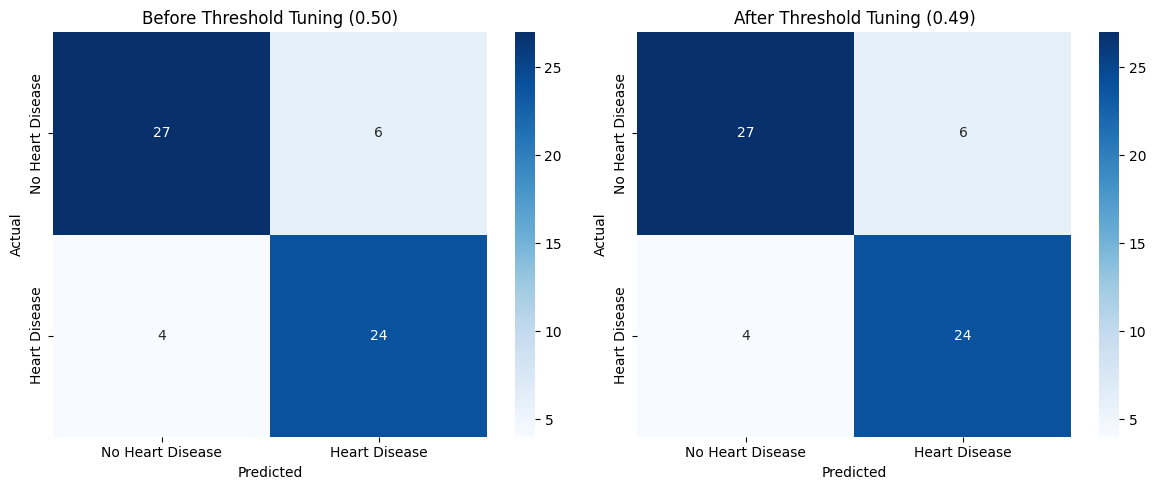

In [ ]:
# Before threshold tuning (0.50)
y_pred_before = (test_probs >= 0.50).astype(int)
cm_before = confusion_matrix(y_test, y_pred_before)

# After threshold tuning
y_pred_after = (test_probs >= best_lower_thresh).astype(int)
cm_after = confusion_matrix(y_test, y_pred_after)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease','Heart Disease'],
            yticklabels=['No Heart Disease','Heart Disease'],
            ax=axes[0])

axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Before Threshold Tuning (0.50)')


sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease','Heart Disease'],
            yticklabels=['No Heart Disease','Heart Disease'],
            ax=axes[1])

axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'After Threshold Tuning ({best_lower_thresh:.2f})')

plt.tight_layout()
plt.show()

Before threshold tuning, the model correctly classified 27 patients without heart disease and 24 patients with heart disease. However, 6 healthy patients were incorrectly predicted as having heart disease (false positives), while 4 patients with heart disease were incorrectly classified as healthy (false negatives).

After threshold tuning, the confusion matrix remained unchanged. This is because the threshold adjustment was very small, changing only from 0.50 to 0.49.

In the medical context, false negatives are more important because patients with heart disease may be missed and experience delays in diagnosis and treatment.

In [ ]:
#Check overfitting
# Training accuracy
train_pred = clf.predict(X_train_smote)
train_acc = accuracy_score(y_train_smote, train_pred)

# Testing accuracy
test_pred = clf.predict(X_test_s)
test_acc = accuracy_score(y_test, test_pred)

print("Before Threshold Tuning:")
print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

# Check overfitting using tuned threshold
# Training accuracy
train_probs = clf.predict_proba(X_train_smote)[:,1]
train_pred = (train_probs >= best_lower_thresh).astype(int)
train_acc = accuracy_score(y_train_smote, train_pred)

# Testing accuracy
test_probs = clf.predict_proba(X_test_s)[:,1]
test_pred = (test_probs >= best_lower_thresh).astype(int)
test_acc = accuracy_score(y_test, test_pred)

print("\nAfter Threshold Tuning:")
print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

Before Threshold Tuning:
Training Accuracy: 0.8779
Testing Accuracy: 0.8361

After Threshold Tuning:
Training Accuracy: 0.8817
Testing Accuracy: 0.8361


The Logistic Regression model achieved a training accuracy of 87.79% and a testing accuracy of 83.61% before threshold tuning. After threshold tuning, the training accuracy increased slightly to 88.17%, while the testing accuracy remained unchanged at 83.61%. The small difference between training and testing accuracy suggests that the model is not overfitting and is able to generalise well to unseen data.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def binary_cross_entropy(y_true, y_prob):
    eps = 1e-15
    return -np.mean(y_true*np.log(y_prob+eps) + (1-y_true)*np.log(1-y_prob+eps))

from sklearn.metrics import log_loss
probs = clf.predict_proba(X_test_s)[:, 1]
my_loss=binary_cross_entropy(y_test, probs)
skl_loss = log_loss(y_test, probs)
print(f'My BCE loss: {my_loss:.5f}')
print(f'Sklearn loss: {skl_loss:.5f}')
assert abs(my_loss - skl_loss) < 0.001, 'Loss mismatch'

My BCE loss: 0.29841
Sklearn loss: 0.29841


The sigmoid function converts the model output into a probability between 0 and 1. BCE was used to measure prediction error for the binary classes, where 0 represents no heart disease and 1 represents heart disease.

The manually calculated BCE loss matched Scikit-learn's result, showing that the implementation was correct.

In [ ]:
class LogisticRegressionGD:

    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n, d = X.shape
        Xb = np.hstack([np.ones((n,1)), X])
        self.w = np.zeros(d + 1)
        for epoch in range(self.epochs):
            z = Xb @ self.w
            y_prob = self.sigmoid(z)
            eps = 1e-15
            loss = -np.mean(
                y*np.log(y_prob + eps)
                + (1-y)*np.log(1-y_prob + eps)
            )
            self.losses.append(loss)
            grad = (1/n) * Xb.T @ (y_prob - y)
            self.w -= self.lr * grad

    def predict_proba(self, X):
        Xb = np.hstack([np.ones((len(X),1)), X])
        return self.sigmoid(Xb @ self.w)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

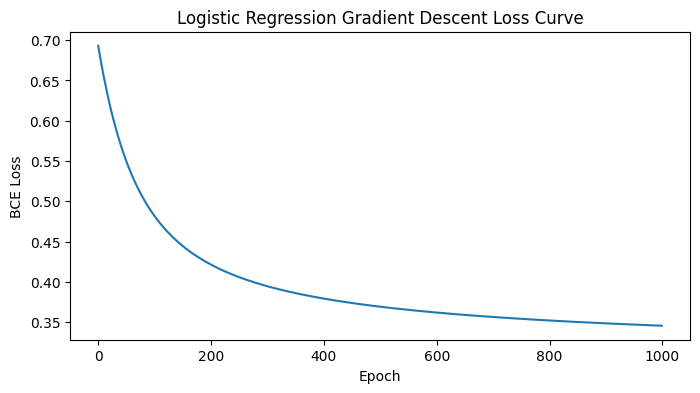

In [ ]:
gd_clf = LogisticRegressionGD(
    lr=0.01,
    epochs=1000
)

gd_clf.fit(X_train_smote, y_train_smote)

plt.figure(figsize=(8,4))
plt.plot(gd_clf.losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Logistic Regression Gradient Descent Loss Curve")
plt.show()

The loss curve shows that the BCE loss decreased as the number of epochs increased. This shows that the model was learning from the training data and improving its predictions over time.


In [ ]:
print(
    "Manual GD ROC-AUC:",
    roc_auc_score(
        y_test,
        gd_clf.predict_proba(X_test_s)
    )
)

Manual GD ROC-AUC: 0.9502164502164503


The manually implemented Logistic Regression model achieved a ROC-AUC score of 0.9502. This shows that the model was able to differentiate between heart disease and non-heart disease cases effectively.

The result is the same as the Scikit-learn implementation, showing that the manual implementation was working correctly and producing reliable predictions.

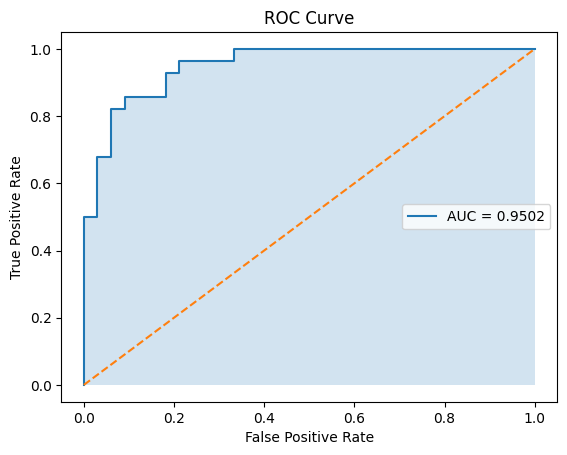

In [ ]:
probs=clf.predict_proba(X_test_s)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


The dashed diagonal line represent a random classifier baseline. The ROC curve is far above the top left the top left corner which indicate good classification performance.

This ROC curve shows that our model performs very well in differentiate between heart disease and non-heart disease cases. The AUC score is 0.9502 which is close to 1 means that the model has strong prediction capability.

# ***Stage B: Ensemble Model***

# Hyperparameter Tuning

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators':[100,200,300],
    'rf__max_depth':[3,5,7,10],
    'rf__min_samples_split':[5,10,15],
    'rf__min_samples_leaf':[2,4,6]
}

grid_rf = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Score:")
print(grid_rf.best_score_)

Best Parameters:
{'rf__max_depth': 3, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 15, 'rf__n_estimators': 300}

Best CV Score:
0.7946146539675356


Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to identify the optimal Random Forest configuration. The search considered different values for the number of trees, maximum tree depth, minimum samples required to split a node and minimum samples required at a leaf node. The best configuration has 300 trees, maximum depth of 3, minimum samples split of 15 and minimum samples leaf of 4 achieving cross-validation F1-score of 0.7946.

# Hyperparameter Search Evidence

In [ ]:
results = pd.DataFrame(grid_rf.cv_results_)

pd.set_option('display.max_colwidth', None)

results[['params',
         'mean_test_score',
         'rank_test_score']]\
         .sort_values('rank_test_score')\
         .head(10)

,params,mean_test_score,rank_test_score
17,"{'rf__max_depth': 3, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 15, 'rf__n_estimators': 300}",0.794615,1
36,"{'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}",0.794199,2
87,"{'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 15, 'rf__n_estimators': 100}",0.792608,3
8,"{'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 15, 'rf__n_estimators': 300}",0.791025,4
60,"{'rf__max_depth': 7, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 15, 'rf__n_estimators': 100}",0.789064,5
14,"{'rf__max_depth': 3, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}",0.786930,6
5,"{'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}",0.785266,7
2,"{'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}",0.785266,7
39,"{'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}",0.784715,9
57,"{'rf__max_depth': 7, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}",0.783861,10


# Train Best Random Forest

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        best_rf.predict_proba(X_test)[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

ROC-AUC: 0.946969696969697


The optimised Random Forest model was trained using the best hyperparameters obtained from GridSearchCV. The model achieved an accuracy of 0.89, a precision of 0.86 a recall of 0.89, an F1-score of 0.88 and a ROC-AUC score of 0.9470. The high recall indicates that the model was able to correctly identify most patients with heart disease which is particularly important in medical diagnosis where false negatives should be minimised.

# Confusion Matrix

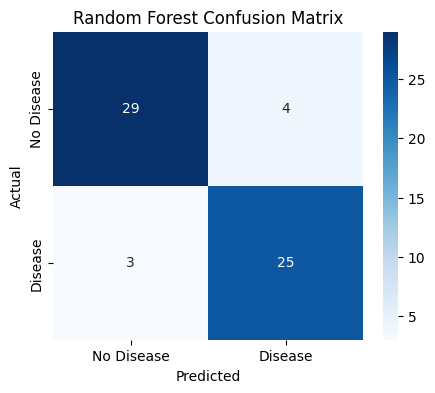

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classified 29 patients without heart disease and 25 patients with heart disease. However, 4 healthy patients were incorrectly predicted as having heart disease, while 3 patients with heart disease were incorrectly classified as healthy. The low number of false negatives indicates that the model was effective in identifying patients with heart disease. Compared to the other models, Random Forest produced the fewest false negatives which contributed to its highest recall score.

# Check Overfitting

In [ ]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8553719008264463
Testing Accuracy: 0.8852459016393442


To assess overfitting, the training and testing accuracies were compared. The Random Forest model achieved a training accuracy of 85.54% and a testing accuracy of 88.52%. This means that the model does not show signs of overfitting and is able to generalise well to unseen data.

# Feature Importance

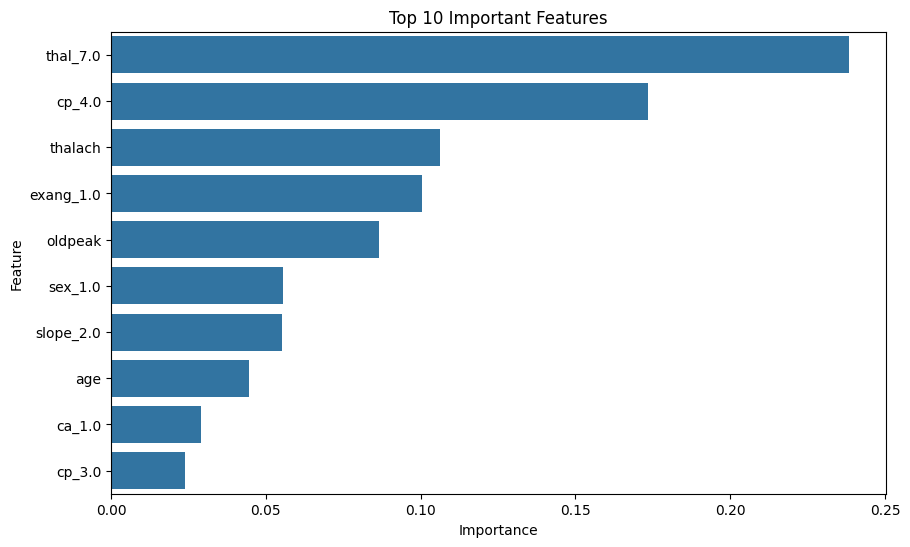

In [ ]:
rf_model = best_rf.named_steps['rf']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')
plt.show()

The most important feature in Random Forest was thal_7.0, cp_4.0, thalach, exang_1.0 and oldpeak. These results are consistent with the correlation heatmap analysis where thal, exang, oldpeak, cp and thalach were also among the features most strongly associated with heart disease. This suggests that the model successfully identified clinically relevant patterns within the dataset.

# ROC curve

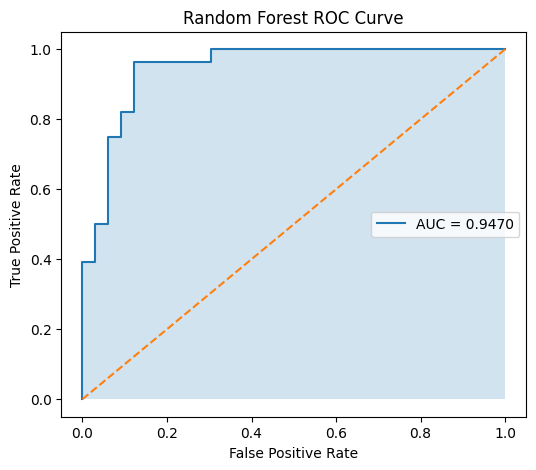

In [ ]:
probs = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

In the ROC Curve, the curve lies close to the top-left corner and achieved a ROC-AUC score of 0.9470. This means that the model can distinguish between patients with and without heart disease well.

# ***Stage C: Deep Learning Model***

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

pipeline_mlp = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(28,),   # Increased complexity for better balance
        activation='relu',
        solver='adam',
        alpha=0.05,                 # L2 regularisation
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,        # prevents overfitting
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=42
    ))
])

pipeline_mlp.fit(X_train, y_train)

print("MLP model trained successfully!")

MLP model trained successfully!


The MLP pipeline consists of three main stages. First SMOTE is applied to training data to helps the model learn patterns from both classes effectively. Next, Features are scaled using StandardScaler. This is to ensure that all input contribute accordingly and model can improved predictive performance. Lastly, classification task was then carried out using a MLP classifier.

The network consisted of single hidden layer contain 28 neurons and applied ReLU activation function to capture complex non-linear relationships within the data. Adam optimiser was used to update model weights efficiently during training. L2 regularisation with alpha value of 0.05 was applied to reduce overfitting risk. Early stopping was enabled to halt training when there is no longer improvement observed. maximum number of training iteration was set to 1000 for the model to converge to an optimal solution.

In [ ]:
y_pred_mlp = pipeline_mlp.predict(X_test)

y_prob_mlp = pipeline_mlp.predict_proba(X_test)[:,1]

In [ ]:
print("=== MLP Classification Report ===\n")

print(classification_report(y_test, y_pred_mlp))

roc_auc = roc_auc_score(y_test, y_prob_mlp)

print("ROC-AUC Score:", roc_auc)

=== MLP Classification Report ===

              precision    recall  f1-score   support

           0       0.75      0.91      0.82        33
           1       0.86      0.64      0.73        28

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

ROC-AUC Score: 0.8571428571428572


MLP achieved an overall accuracy of 78.69% on test dataset and produced ROC-AUC score of 0.8571. This shows a moderately good performance although the score is lesser than both Logistic Regression and Random Forest model.

Although the recall is high for class 0 (no heart disease), the model achieved a recall of 0.64 for class 1 (heart disease). The lower recall suggests that approximately 36% of actual heart disease cases were not detected

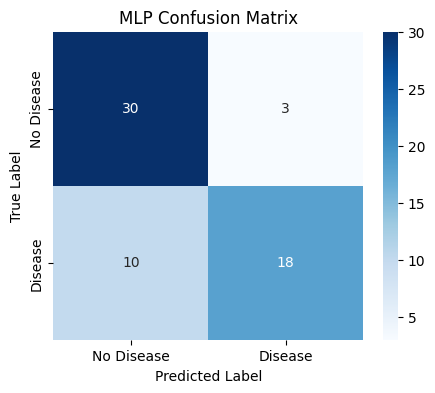

In [ ]:
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP Confusion Matrix")

plt.show()

Compared to Logistic Regression and Random Forest, the MLP model generated higher number of false negatives (10 cases). This results in lower recall for heart disease detection. Since detecting patients with heart disease is the main objective of this study. MLP may not be the best model despite showing a quite good generalisation and minimal overfitting.

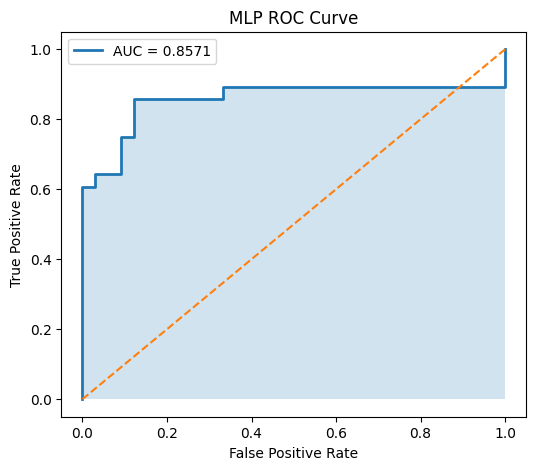

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.fill_between(fpr, tpr, alpha=0.2)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP ROC Curve')
plt.legend()
plt.show()

ROC curve demonstrates the ability of the model to distinguish between patients with heart disease and without heart disease. The value 0.8571 and the position of the curve that is above the diagonal reference line confirms that model performs much better than random guessing.

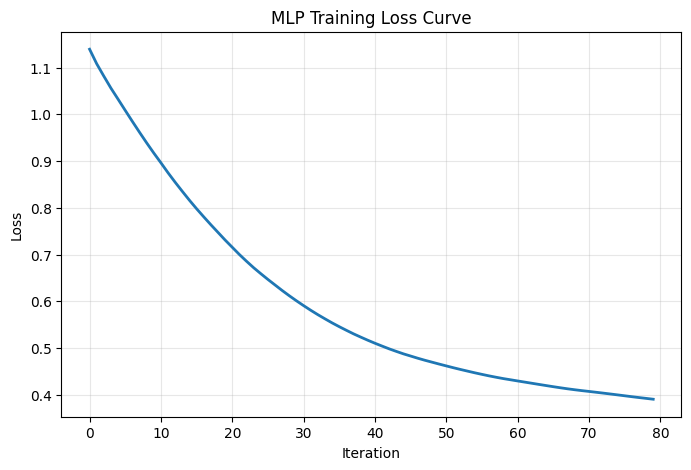

In [ ]:
mlp_model = pipeline_mlp.named_steps['mlp']

plt.figure(figsize=(8,5))

plt.plot(
    mlp_model.loss_curve_,
    linewidth=2
)

plt.xlabel('Iteration')

plt.ylabel('Loss')

plt.title('MLP Training Loss Curve')

plt.grid(True, alpha=0.3)

plt.show()

Training loss curve exhibited a smooth downward trend throughout optimisation process. This behaviour indicates that the neural network learned meaningful patterns from training data and converged in a stable manner. Since there is no big fluctuations in the loss values, the model achieved efficient optimisation and trusted to produce reliable results.

In [ ]:
train_acc = pipeline_mlp.score(X_train, y_train)

test_acc = pipeline_mlp.score(X_test, y_test)

print("Training Accuracy:", train_acc)

print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8140495867768595
Testing Accuracy: 0.7868852459016393


In [ ]:
difference = abs(train_acc - test_acc)

print("Accuracy Difference:", round(difference*100,2), "%")

if difference < 0.05:
    print("No significant overfitting detected.")
else:
    print("Potential overfitting detected.")

Accuracy Difference: 2.72 %
No significant overfitting detected.


In [ ]:
mlp_model = pipeline_mlp.named_steps['mlp']

print("Input Features:", X_train_s.shape[1])

print("Hidden Layers:", mlp_model.hidden_layer_sizes)

print("Activation Function:", mlp_model.activation)

print("Output Layer: 1 Neuron (Binary Classification)")

Input Features: 20
Hidden Layers: (28,)
Activation Function: relu
Output Layer: 1 Neuron (Binary Classification)


## **Summary**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'MLP'],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, test_probs),
        roc_auc_score(y_test, probs),
        roc_auc_score(y_test, y_prob_mlp)
    ]
})

summary = summary.round(4)

display(summary)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8361,0.8000,0.8571,0.8276,0.9502
1,Random Forest,0.8852,0.8621,0.8929,0.8772,0.9470
2,MLP,0.7869,0.8571,0.6429,0.7347,0.8571
